# Exploratory Data Analysis: Predicting secondary School Performance in England (ANN)
**MRes First Progress Assessment — EDA Amendments**

1. **Data merging / homogenisation strategy** (Sections 3–5)
2. **Data statistical profiles with exemplary correlations** (Sections 6–7)
3. **Data quality statements** (Section 8)



## 1. Business / Research Understanding

Following the CRISP-DM style

In [150]:
# DO NOT CHANGE THE VARIABLE NAME
business_understanding = {
    "stakeholder": (
        "Department for Education, Ofsted, local authorities and school "
        "leaders who allocate support and funding to state-funded secondary "
        "schools in England."
    ),
    "policy_problem": (
        "School performance varies with socio-economic context, but current "
        "monitoring (periodic inspection, published league tables) identifies "
        "struggling schools late. A predictive, interpretable model could "
        "flag at-risk schools earlier."
    ),
    "analytical_objective": (
        "Integrate DfE performance tables, Ofsted inspection outcomes and "
        "ONS/IMD socio-economic indicators at school level, and train an ANN "
        "to predict school performance (Ofsted overall effectiveness / "
        "Progress 8), explained with SHAP and LIME."
    ),
    "success_criteria": (
        "A homogenised school-level dataset covering >90% of eligible "
        "secondary schools; an ANN that outperforms linear and tree-based "
        "baselines on macro-F1 (classification) or RMSE (regression); "
        "explanations consistent with the education literature."
    ),
}
business_understanding


{'stakeholder': 'Department for Education, Ofsted, local authorities and school leaders who allocate support and funding to state-funded secondary schools in England.',
 'policy_problem': 'School performance varies with socio-economic context, but current monitoring (periodic inspection, published league tables) identifies struggling schools late. A predictive, interpretable model could flag at-risk schools earlier.',
 'analytical_objective': 'Integrate DfE performance tables, Ofsted inspection outcomes and ONS/IMD socio-economic indicators at school level, and train an ANN to predict school performance (Ofsted overall effectiveness / Progress 8), explained with SHAP and LIME.',
 'success_criteria': 'A homogenised school-level dataset covering >90% of eligible secondary schools; an ANN that outperforms linear and tree-based baselines on macro-F1 (classification) or RMSE (regression); explanations consistent with the education literature.'}

## 2. Data Acquisition

All datasets are open UK government data. 

GIAS provides, per school, the `URN`, phase, status, **postcode and the LSOA code** — so it acts as the *bridge* between DfE/Ofsted data (keyed on URN) and IMD data (keyed on LSOA), without needing the full ONS Postcode Directory.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
DATA = Path("datasets")

def load_csv(path, **kw):
    """Robust loader: keeps URN/LSOA codes as strings, tolerates encodings."""
    for enc in ("utf-8", "cp1252", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False,
                               dtype=str, **kw)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError(f"Could not decode {path}")

gias   = load_csv('../../data/gias_establishments.csv')
ks4_23 = load_csv('../../data/ks4_2023.csv')
ks4_24 = load_csv('../../data/ks4_2024.csv')
ks4_25 = load_csv('../../data/ks4_2025.csv')
ofsted = load_csv('../../data/ofsted_mi.csv')
imd    = load_csv('../../data/imd2019.csv')



for name, df in [("GIAS", gias), ("KS4 2022/23", ks4_23),
                 ("KS4 2023/24", ks4_24),("KS4 2024/25", ks4_25), ("Ofsted MI", ofsted),
                 ("IMD 2019", imd)]:
    print(f"{name:<12} rows={len(df):>7,}  cols={df.shape[1]}")
    
#gias.describe()



GIAS         rows= 52,450  cols=135
KS4 2022/23  rows=  5,813  cols=515
KS4 2023/24  rows=  5,864  cols=429
KS4 2024/25  rows=  5,910  cols=497
Ofsted MI    rows= 21,958  cols=85
IMD 2019     rows= 33,755  cols=56


### 2.1 Column harmonisation

Government files change column names between releases (e.g. `URN` vs `School URN`, `LSOA (code)` vs `LSOA code (2011)`). Names were normalised

In [2]:
def norm_cols(df):
    df = df.copy()
    df.columns = (df.columns.str.strip().str.lower()
                    .str.replace(r"[^a-z0-9]+", "_", regex=True)
                    .str.strip("_"))
    return df

gias, ks4_23, ks4_24, ks4_25, ofsted, imd = map(norm_cols, [gias, ks4_23, ks4_24, ks4_25, ofsted, imd])

def find_col(df, *candidates, contains=None):
    """Locate a column by exact candidates first, then substring."""
    for c in candidates:
        if c in df.columns:
            return c
    if contains:
        hits = [c for c in df.columns if contains in c]
        if hits:
            return hits[0]
    raise KeyError(f"None of {candidates} (or *{contains}*) found")

URN_GIAS   = find_col(gias, "urn")
LSOA_GIAS  = find_col(gias, "lsoa_code", contains="lsoa")
URN_KS4    = find_col(ks4_23, "urn")
URN_OFSTED = find_col(ofsted, "urn", contains="urn")
LSOA_IMD   = find_col(imd, "lsoa_code_2011", contains="lsoa_code")

print("Key columns resolved:",
      dict(gias=URN_GIAS, gias_lsoa=LSOA_GIAS, ks4=URN_KS4,
           ofsted=URN_OFSTED, imd=LSOA_IMD))

           


Key columns resolved: {'gias': 'urn', 'gias_lsoa': 'lsoa_code', 'ks4': 'urn', 'ofsted': 'urn', 'imd': 'lsoa_code_2021'}


## 3. Defining the Analysis Population (Homogenisation step 1)



In [3]:
g = gias.copy()

phase_col  = find_col(g, "phaseofeducation_name", contains="phase")
status_col = find_col(g, "establishmentstatus_name", contains="status")
type_col   = find_col(g, "typeofestablishment_name", contains="typeofestablishment")

print(g[phase_col].value_counts(dropna=False).head(10), "\n")
print(g[status_col].value_counts(dropna=False).head(10))


phaseofeducation_name
Primary                    30630
Not applicable             12542
Secondary                   6976
Middle deemed secondary      630
Nursery                      619
16 plus                      581
Middle deemed primary        260
All-through                  212
Name: count, dtype: int64 

establishmentstatus_name
Open                           27179
Closed                         25188
Open, but proposed to close       49
Proposed to open                  34
Name: count, dtype: int64


In [4]:
SECONDARY_PHASES = ["Secondary", "All-through", "Middle deemed secondary"]
INDEPENDENT_TYPES = g[type_col].dropna().unique()
INDEPENDENT_TYPES = [t for t in INDEPENDENT_TYPES if "independent" in t.lower()]

spine = g[
    g[status_col].str.contains("Open", case=False, na=False)
    & g[phase_col].isin(SECONDARY_PHASES)
    & ~g[type_col].isin(INDEPENDENT_TYPES)
].copy()

spine["urn"] = spine[URN_GIAS].str.strip()
spine = spine.drop_duplicates(subset="urn")
print(f"Spine: {len(spine):,} open state-funded secondary schools")


Spine: 3,439 open state-funded secondary schools


## 4. Data Merging / Homogenisation Strategy (Homogenisation step 2)


1. Spine = GIAS open state-funded secondary schools (unique `URN`).
2. URN joins- (left joins onto the GIAS): DfE KS4 tables (per year) and Ofsted MI both key on `URN`.
3. GIAS supplies each school's LSOA code; IMD 2019 is keyed on LSOA, so deprivation attaches via `URN → LSOA → IMD`.
4. Each academic year of KS4 data becomes a suffixed column set (`p8_2023`, `p8_2024`), producing one row per school (wide format) suitable for the ANN.
5. Join-loss audit: after every merge recorded how many spine schools failed to match and why — this feeds directly into the data quality statement.

```
GIAS spine (URN, LSOA) ──URN──▶ KS4 2022/23
                        └URN──▶ KS4 2023/24
                        └URN──▶ Ofsted MI (latest inspection)
            LSOA──▶ IMD 2019 (deciles & domain scores)
```


In [5]:
audit = []  # join-loss audit log

def left_join_audit(base, other, on_left, on_right, name, cols=None):
    other = other.copy()
    other[on_right] = other[on_right].astype(str).str.strip()
    if cols:
        other = other[[on_right] + cols]
    other = other.drop_duplicates(subset=on_right)
    merged = base.merge(other, how="left",
                        left_on=on_left, right_on=on_right,
                        suffixes=("", f"_{name}"))
    key_probe = cols[0] if cols else on_right
    matched = merged[key_probe].notna().sum() if key_probe in merged else np.nan
    audit.append({"merge": name, "spine_rows": len(base),
                  "matched": matched,
                  "match_rate_%": round(100 * matched / len(base), 1)})
    return merged




In [6]:
# --- pick the analysis variables from each source 
P8_COL   = find_col(ks4_23, "p8mea", contains="p8mea")      # Progress 8
A8_COL   = find_col(ks4_23, "att8scr", contains="att8")     # Attainment 8
FSM_COL  = find_col(ks4_23, "ptfsm6cla1a", contains="fsm")  # % disadvantaged
OE_COL   = find_col(ofsted, "overall_effectiveness", contains="effectiveness")
IMD_DEC  = find_col(imd, contains="index_of_multiple_deprivation_imd_decile")
IMD_SCORE= find_col(imd, contains="index_of_multiple_deprivation_imd_score")
INC_SCORE= find_col(imd, contains="income_score")
EDU_SCORE= find_col(imd, contains="education_skills_and_training_score")



df = spine[["urn", LSOA_GIAS]].rename(columns={LSOA_GIAS: "lsoa"})

for yr, ks4 in [("2023", ks4_23), ("2024", ks4_24), ("2025", ks4_25)]:
    p8  = find_col(ks4, "p8mea")
    a8  = find_col(ks4, "att8scr")
    fsm = find_col(ks4, "ptfsm6cla1a")
    tmp = ks4.rename(columns={p8: f"p8_{yr}", a8: f"a8_{yr}",
                              fsm: f"fsm_pct_{yr}"})
    df = left_join_audit(df, tmp, "urn", URN_KS4, f"ks4_{yr}",
                         cols=[f"fsm_pct_{yr}", f"a8_{yr}", f"p8_{yr}"])  # FSM first = audit probe

df = left_join_audit(df, ofsted.rename(columns={OE_COL: "ofsted_grade"}),
                     "urn", URN_OFSTED, "ofsted", cols=["ofsted_grade"])

df = left_join_audit(df, imd.rename(columns={IMD_DEC: "imd_decile",
                                             IMD_SCORE: "imd_score",
                                             INC_SCORE: "income_score",
                                             EDU_SCORE: "edu_skills_score"}),
                     "lsoa", LSOA_IMD, "imd",
                     cols=["imd_decile", "imd_score",
                           "income_score", "edu_skills_score"])

pd.DataFrame(audit)

# --- Ofsted merge ---
OE_COL = find_col(ofsted, "latest_oeif_overall_effectiveness", contains="oeif")
df = left_join_audit(df, ofsted.rename(columns={OE_COL: "ofsted_grade"}),
                     "urn", URN_OFSTED, "ofsted", cols=["ofsted_grade"])

# --- split the Ofsted audit: join success vs grade availability ---
urn_matched = df["urn"].isin(ofsted[URN_OFSTED].astype(str).str.strip())
print(f"Ofsted URN matched:        {urn_matched.mean():.1%}")
print(f"Grade available (overall): {df['ofsted_grade'].notna().mean():.1%}")
print(f"Grade available among matched: "
      f"{df.loc[urn_matched, 'ofsted_grade'].notna().mean():.1%}")




Ofsted URN matched:        99.4%
Grade available (overall): 69.5%
Grade available among matched: 70.0%


In [7]:
# --- type conversion after merging (gov CSVs use "SUPP"/"NE"/"NA" markers) ---
SUPPRESSION_MARKERS = ["SUPP", "NE", "NA", "NP", "LOWCOV", ""]

num_cols = [c for c in df.columns
            if c.startswith(("p8_", "a8_", "fsm_pct_", "imd_", "income_", "edu_"))]
for c in num_cols:
    df[c] = (df[c].replace(SUPPRESSION_MARKERS, np.nan)
                  .str.replace("%", "", regex=False)
                  .astype(float))

df["imd_decile"] = df["imd_decile"].astype("Int64")

# Ofsted grade → ordered categorical / numeric code
grade_order = ["Outstanding", "Good", "Requires improvement", "Inadequate"]

raw = df["ofsted_grade"].astype(str).str.strip()

label_map = {"1": "Outstanding", "2": "Good",
             "3": "Requires improvement", "4": "Inadequate"}
df["ofsted_grade_label"] = raw.map(label_map)          # "Not judged"/NaN → NaN

df["ofsted_num"] = raw.map({"1": 4, "2": 3, "3": 2, "4": 1}).astype("Int64")
# 4 = Outstanding ... 1 = Inadequate (higher = better, so correlations with P8 read positively)

grade_order = ["Outstanding", "Good", "Requires improvement", "Inadequate"]
print(df["ofsted_grade_label"].value_counts(dropna=False))

df["ofsted_num"] = df["ofsted_grade_label"].map(
    {g: i for i, g in enumerate(grade_order[::-1], start=1)})  # 4=Outstanding

df.head()


ofsted_grade_label
NaN                     1625
Good                    1236
Outstanding              272
Requires improvement     251
Inadequate                55
Name: count, dtype: int64


,urn,lsoa,fsm_pct_2023,a8_2023,p8_2023,fsm_pct_2024,a8_2024,p8_2024,fsm_pct_2025,a8_2025,p8_2025,ofsted_grade,lsoa_code_2021,imd_decile,imd_score,income_score,edu_skills_score,ofsted_grade_ofsted,ofsted_grade_label,ofsted_num
0,100049,E01000902,63.0,41.7,-0.28,72.4,44.2,-0.20,80.1,41.5,NaN,NaN,E01000902,2,38.816,0.503,22.292,NaN,NaN,NaN
1,100050,E01000912,42.0,59.1,0.61,41.8,58.9,0.50,40.2,57.1,NaN,1,E01000912,3,31.912,0.389,10.965,1,Outstanding,4.0
2,100051,E01000952,59.0,43.8,-0.06,69.6,44.5,-0.27,72.0,42.6,NaN,NaN,E01000952,2,39.434,0.412,27.444,NaN,NaN,NaN
3,100052,E01000871,45.0,44.6,-0.03,50.7,41.2,-0.46,55.0,43.1,NaN,2,E01000871,6,16.839,0.204,2.661,2,Good,3.0
4,100053,E01000928,37.0,50.3,-0.16,37.9,50.4,-0.30,51.4,49.9,NaN,NaN,E01000928,4,22.474,0.248,5.827,NaN,NaN,NaN


## 5. Statistical Profiles

Per-variable profile: count, missing %, central tendency, dispersion, skewness. Skewness informs Phase-2 preprocessing.

In [8]:
profile_cols = ["p8_2023", "p8_2024", "a8_2023", "a8_2024", "a8_2025",
                "fsm_pct_2023", "fsm_pct_2024", "fsm_pct_2025",
                "imd_score", "income_score", "edu_skills_score", "ofsted_num"]
profile_cols = [c for c in profile_cols if c in df.columns]

prof = df[profile_cols].describe().T
prof["missing_%"] = (df[profile_cols].isna().mean() * 100).round(1)
prof["skew"] = df[profile_cols].skew().round(2)
prof.round(2)




,count,mean,std,min,25%,50%,75%,max,missing_%,skew
p8_2023,3060.0,-0.00,0.51,-3.30,-0.33,-0.01,0.33,2.37,11.0,-0.02
p8_2024,3141.0,0.00,0.52,-3.84,-0.33,0.00,0.34,2.56,8.7,-0.14
a8_2023,3063.0,47.15,9.28,18.80,41.20,46.10,51.50,87.60,10.9,1.03
a8_2024,3142.0,46.94,9.47,0.80,40.80,45.90,51.30,86.60,8.6,1.00
a8_2025,3215.0,46.94,9.32,0.90,41.00,45.80,51.10,87.30,6.5,1.05
fsm_pct_2023,3063.0,26.50,14.43,0.00,15.00,24.00,35.00,93.00,10.9,0.79
fsm_pct_2024,3142.0,26.52,14.04,0.00,15.70,24.20,35.20,82.80,8.6,0.70
fsm_pct_2025,3215.0,28.30,14.47,0.00,17.25,25.80,37.25,80.10,6.5,0.66
imd_score,3432.0,20.56,14.74,0.71,9.28,16.67,28.55,82.44,0.2,1.14
income_score,3432.0,0.23,0.15,0.01,0.11,0.19,0.31,1.00,0.2,1.11


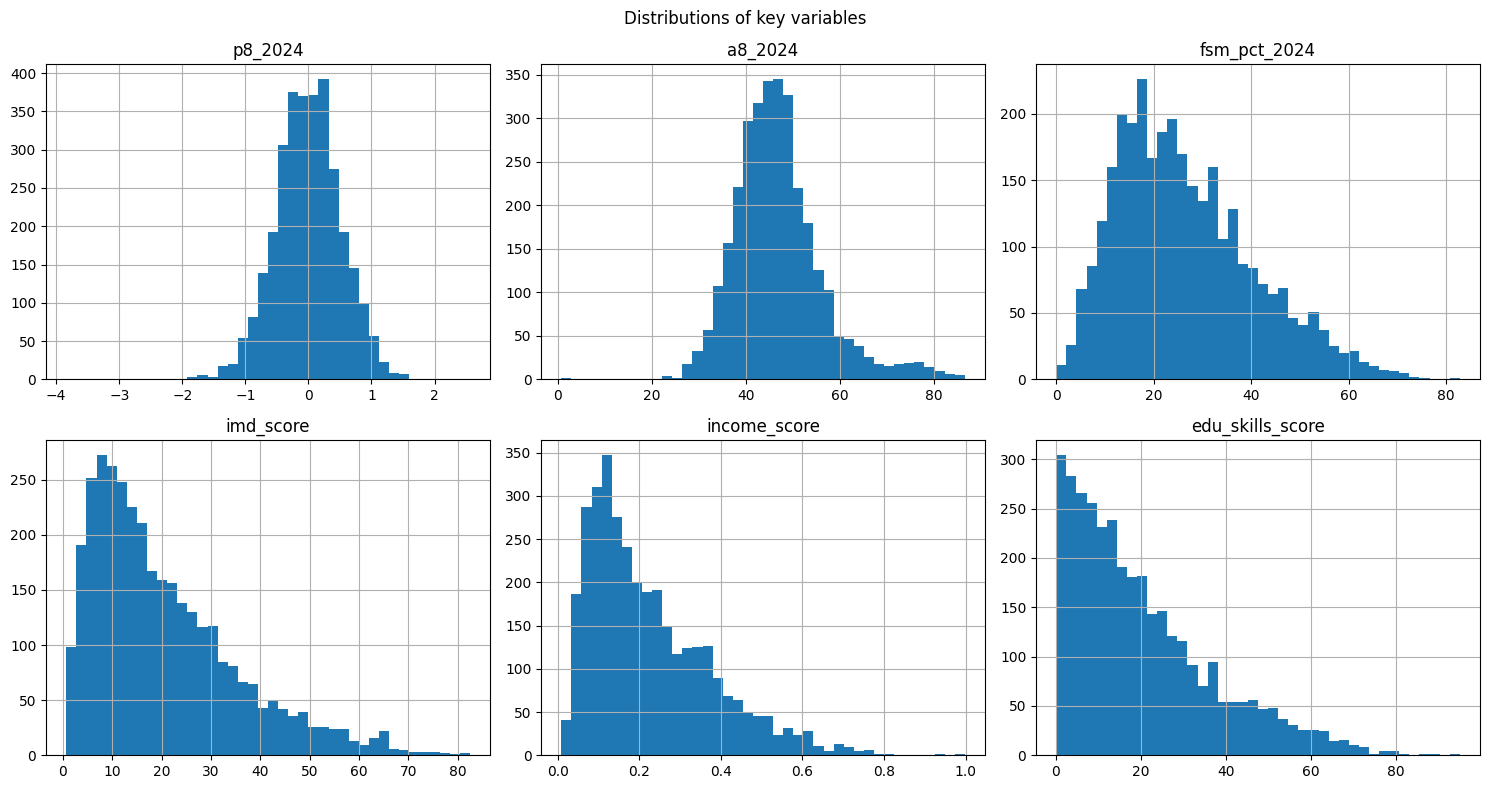

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = ["p8_2024", "a8_2024", "fsm_pct_2024",
             "imd_score", "income_score", "edu_skills_score"]
for ax, c in zip(axes.ravel(), plot_cols):
    if c in df.columns:
        df[c].dropna().hist(bins=40, ax=ax)
        ax.set_title(c)
plt.suptitle("Distributions of key variables")
plt.tight_layout()
plt.show()


ofsted_grade_label
Good                    1236
Outstanding              272
Requires improvement     251
Inadequate                55
Name: count, dtype: int64 



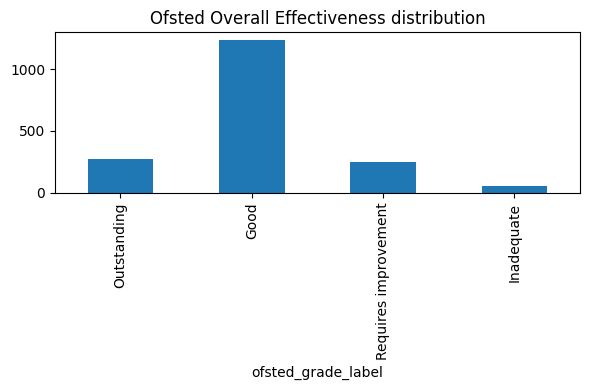

In [10]:
# Target variable: Ofsted grade distribution (class imbalance check)
counts = df["ofsted_grade_label"].value_counts()
print(counts, "\n")
counts.reindex(grade_order).plot(kind="bar", figsize=(6, 4),
                                 title="Ofsted Overall Effectiveness distribution")
plt.tight_layout(); plt.show()


## 6. Exemplary Correlations


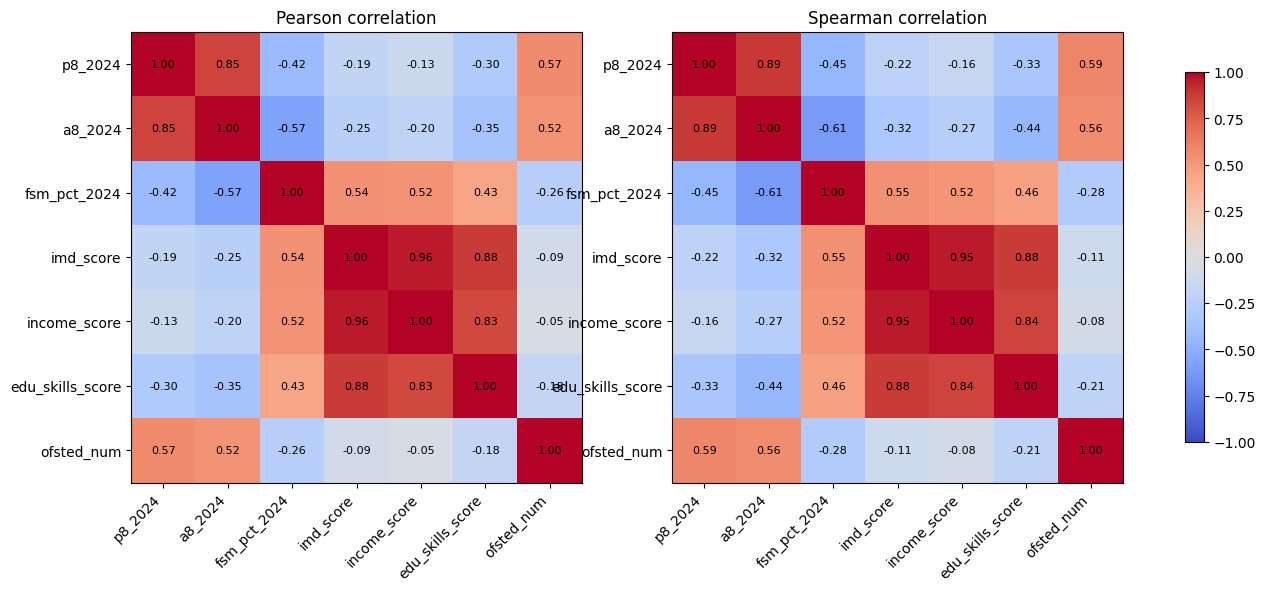

In [11]:
df["ofsted_num"] = df["ofsted_num"].astype(float)
corr_cols = [c for c in ["p8_2024", "a8_2024", "fsm_pct_2024",
                         "imd_score", "income_score",
                         "edu_skills_score", "ofsted_num"] if c in df.columns]

pearson  = df[corr_cols].corr(method="pearson")
spearman = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (m, title) in zip(axes, [(pearson, "Pearson"), (spearman, "Spearman")]):
    im = ax.imshow(m, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{title} correlation")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


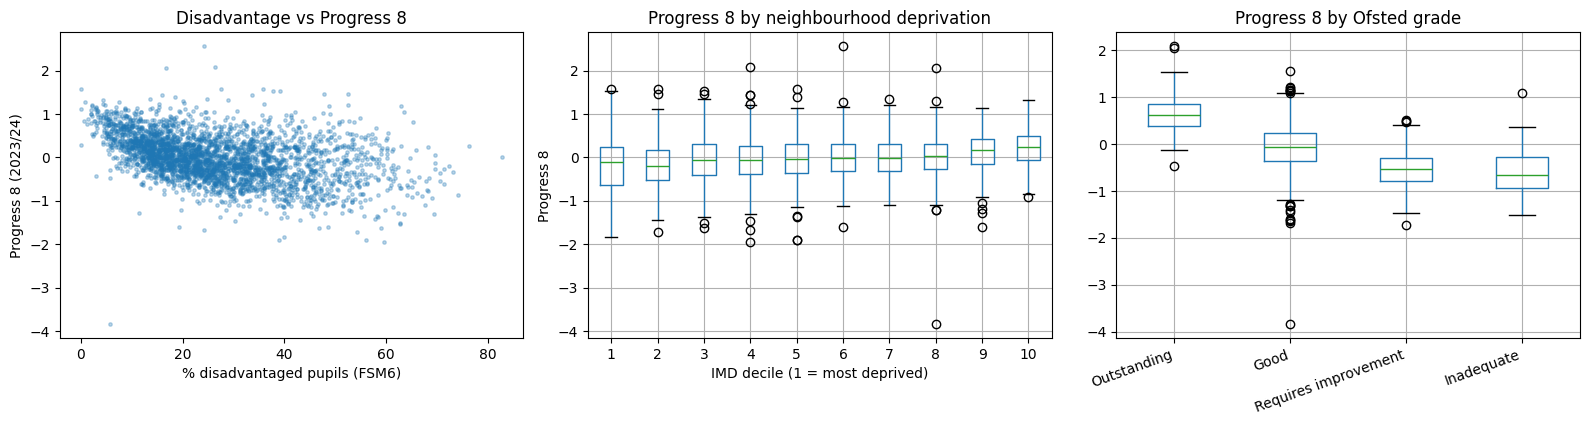

In [12]:
# Exemplary bivariate relationships for the report

# Make the grade an ordered categorical BEFORE plotting, so boxplots follow this order
grade_order = ["Outstanding", "Good", "Requires improvement", "Inadequate"]
df["ofsted_grade_label"] = pd.Categorical(df["ofsted_grade_label"],
                                          categories=grade_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: FSM% vs Progress 8
axes[0].scatter(df["fsm_pct_2024"], df["p8_2024"], s=6, alpha=0.3)
axes[0].set_xlabel("% disadvantaged pupils (FSM6)")
axes[0].set_ylabel("Progress 8 (2023/24)")
axes[0].set_title("Disadvantage vs Progress 8")

# Panel 2: Progress 8 by IMD decile
df.boxplot(column="p8_2024", by="imd_decile", ax=axes[1])
axes[1].set_xlabel("IMD decile (1 = most deprived)")
axes[1].set_ylabel("Progress 8")
axes[1].set_title("Progress 8 by neighbourhood deprivation")

# Panel 3: Progress 8 by Ofsted grade (ordered best → worst)
df.boxplot(column="p8_2024", by="ofsted_grade_label", ax=axes[2])
axes[2].set_xticklabels(grade_order, rotation=20, ha="right")
axes[2].set_title("Progress 8 by Ofsted grade")
axes[2].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.savefig("fig_A8_exemplary_relationships.png", dpi=200, bbox_inches="tight")
plt.show()

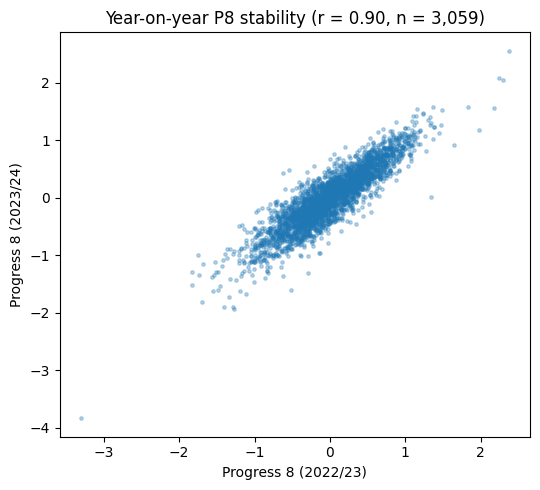

In [13]:
# Year-on-year stability of Progress 8 — how much signal history carries
both = df[["p8_2023", "p8_2024"]].dropna()
r = both.corr().iloc[0, 1]
plt.figure(figsize=(5.5, 5))
plt.scatter(both["p8_2023"], both["p8_2024"], s=6, alpha=0.3)
plt.xlabel("Progress 8 (2022/23)"); plt.ylabel("Progress 8 (2023/24)")
plt.title(f"Year-on-year P8 stability (r = {r:.2f}, n = {len(both):,})")
plt.tight_layout(); plt.show()


In [14]:
# Multicollinearity among IMD domain scores — matters for SHAP interpretation
imd_domains = [c for c in ["imd_score", "income_score", "edu_skills_score"] if c in df.columns]
df[imd_domains].corr().round(2)


,imd_score,income_score,edu_skills_score
imd_score,1.00,0.96,0.88
income_score,0.96,1.00,0.83
edu_skills_score,0.88,0.83,1.00


## 7. Missingness Analysis
Find out missing values are random or related to deprivation.

Missing % per variable:
 ofsted_num          47.3
p8_2023             11.0
fsm_pct_2023        10.9
a8_2023             10.9
p8_2024              8.7
a8_2024              8.6
fsm_pct_2024         8.6
a8_2025              6.5
fsm_pct_2025         6.5
imd_score            0.2
income_score         0.2
edu_skills_score     0.2
dtype: float64 

Missing P8 by IMD decile (%):
 imd_decile
1      9.4
2      9.1
3      5.5
4      9.0
5      8.1
6      9.6
7      7.8
8     10.3
9      7.2
10     9.1
Name: p8_missing, dtype: float64 

Missing Ofsted grade by IMD decile (%):
 imd_decile
1     44.2
2     48.5
3     42.6
4     46.7
5     48.0
6     46.4
7     47.2
8     49.7
9     46.9
10    50.7
Name: grade_missing, dtype: float64


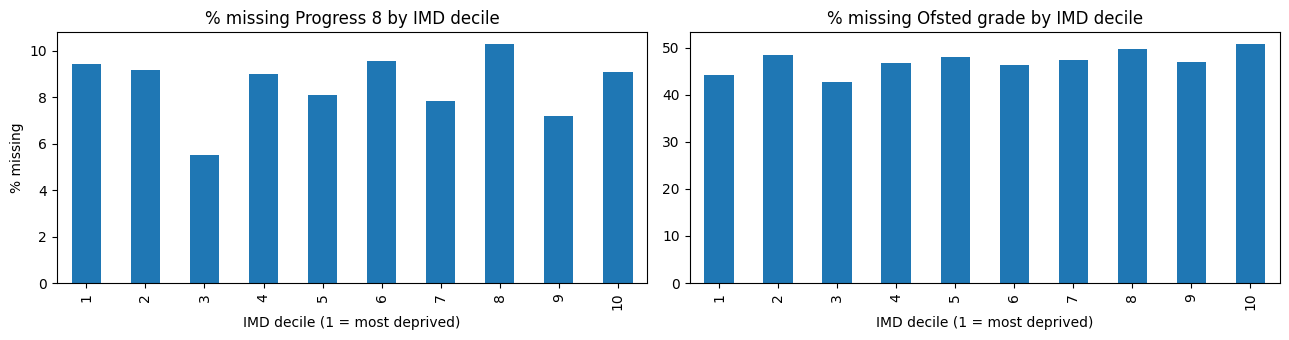

In [15]:
# ── Section 7: Missingness analysis ──────────────────────────────────────

# 1. Missing % per variable
missing_tbl = (df[profile_cols].isna().mean() * 100).round(1).sort_values(ascending=False)
print("Missing % per variable:\n", missing_tbl, "\n")

# 2. Informative-missingness check: is missingness related to deprivation?
df["p8_missing"]    = df["p8_2024"].isna()
df["grade_missing"] = df["ofsted_grade_label"].isna()

p8_by_dec    = df.groupby("imd_decile")["p8_missing"].mean() * 100
grade_by_dec = df.groupby("imd_decile")["grade_missing"].mean() * 100

print("Missing P8 by IMD decile (%):\n", p8_by_dec.round(1), "\n")
print("Missing Ofsted grade by IMD decile (%):\n", grade_by_dec.round(1))

# 3. Figure A.9 — two panels, saved for the appendix
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
p8_by_dec.plot(kind="bar", ax=axes[0],
               title="% missing Progress 8 by IMD decile")
grade_by_dec.plot(kind="bar", ax=axes[1],
                  title="% missing Ofsted grade by IMD decile")
for ax in axes:
    ax.set_xlabel("IMD decile (1 = most deprived)")
axes[0].set_ylabel("% missing")
plt.tight_layout()
plt.savefig("fig_A9_missingness_by_decile.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# flag statistical outliers on the key measures
checks = {"a8_2025": 10, "p8_2024": None}   # A8 below 10, P8 beyond ±3 SD

low_a8 = df[df["a8_2025"] < 10]
print(f"A8 2025 < 10: {len(low_a8)} schools")

p8_z = (df["p8_2024"] - df["p8_2024"].mean()) / df["p8_2024"].std()
extreme_p8 = df[p8_z.abs() > 3]
print(f"P8 2024 beyond ±3 SD: {len(extreme_p8)} schools")

A8 2025 < 10: 1 schools
P8 2024 beyond ±3 SD: 17 schools
